In [1]:
import os
os.chdir('../..')
os.getcwd()

'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [14]:
import pandas as pd
from Bio import SeqIO
import pickle

# Read the TSV file
df = pd.read_csv('output/motifs/positive/ame_output/sequences.tsv', sep='\t')

# Filter for RNP4F motifs in tp class
filtered_df = df[(df['motif_ALT_ID'] == 'RNP4F') & (df['class'] == 'tp')]


In [15]:
filtered_df

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class
28756,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_3344_1,7551.0,150.20200,tp
28757,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_1837_0,4110.0,138.83300,tp
28758,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_2620_0,5828.0,113.49400,tp
28759,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_351_1,722.0,92.42510,tp
28760,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_1590_3,3541.0,85.85110,tp
...,...,...,...,...,...,...,...
30251,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_1416_1,3116.0,1.26773,tp
30252,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_37_1,56.0,1.26763,tp
30253,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_2469_0,5458.0,1.26700,tp
30254,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_2649_0,5901.0,1.26582,tp


In [16]:
# Read motif sequences
motif_seqs = {}
for record in SeqIO.parse('output/motifs/positive/motif_seqs.fasta', 'fasta'):
    motif_seqs[record.id] = str(record.seq)


In [17]:
motif_seqs

{'motif_seq_0_0': 'UGAUAUUACCCACUAUGUAAAUACAAUAUAUAUAUAUAUAUAUAUAUAGGCUUUUG',
 'motif_seq_0_1': 'UAUGGAAGGGCGGUCAAUAUGGAGAGAGGCAGGGACAAACUAAAAUAUC',
 'motif_seq_0_2': 'AUGUAUGUACAUAAAUAACUAUAGAUAACAGCAAUUAAUCAGAAAGCC',
 'motif_seq_0_3': 'UAGACACAAAUACAUACAUAAGCAAGUGACCCAUGCAAAUGCAUAU',
 'motif_seq_2_0': 'AGAGACAGGCAGAAAGAAUAGAAAGAA',
 'motif_seq_2_1': 'AUCAAAGCCUUAGCC',
 'motif_seq_2_2': 'AGCAAGAGGUGGAA',
 'motif_seq_2_3': 'ACAUCUGUCG',
 'motif_seq_3_0': 'CGCUGGCAACUAAAAGUUUACCAAUAAAAUAG',
 'motif_seq_4_0': 'GACGCAAUACCCUAGAC',
 'motif_seq_6_0': 'AAUUACACUGGCCAGUAUUAAAUUAUC',
 'motif_seq_6_1': 'UCGAUGGUUGGG',
 'motif_seq_7_0': 'GAGUAUCUUCAAGGACACC',
 'motif_seq_7_1': 'AGAAAAAUUC',
 'motif_seq_8_0': 'GCUGGUUUUGUGUGGAAUUAAUAUUAAAUAUUACCUACC',
 'motif_seq_8_1': 'ACAGCUACC',
 'motif_seq_9_0': 'AUUUAGCAUUUUUUC',
 'motif_seq_10_0': 'UGUAUUAAUUAC',
 'motif_seq_13_0': 'UGAUUAUUUUUUUAGAC',
 'motif_seq_13_1': 'AGAGGCAGUGG',
 'motif_seq_14_0': 'UACUGACUGAAA',
 'motif_seq_16_0': 'CGAUAGUUUGUGGCAUU

In [18]:

# Read train sequences
train_seqs = {}
for record in SeqIO.parse('output/data/decay/train.fasta', 'fasta'):
    train_seqs[record.description.split(' ')[1]] = str(record.seq)


In [19]:
train_seqs

{'FBtr0081843': 'UCGAUACUAUCGCGAGUGCUAGCUGACGCUGGUCUGGUUUUAUUUUAUGUUAACGGGAGUGAUCUUGCGUACAAACAAUAACACGGAAUCGCAGUGAAAGGGCGUUGCACAAAUGACAGUGUUUUGGCAAAAUGCCCGGGCUAGUUUUGACCACGUUUAGCAGUGCCUAGAACGCAGAGUGCGCGACGCUAAAACAAGAGAACCGCGACAAAACAAAACGCGGAAACGCAUAAAGUGAAAAAAAAAACACAAACGCAGACAGCGAACUUUGGACACAGACAAUCGUAAACGCACGGGGAAAACAAAGAAAAACGAAGAA,GCGGAAUAAUGCCUCUAGUUAUGUCAUUAGUUAGUUUUUAUUUAUGGAAGGGCGGUCAAUAUGGAGAGAGGCAGGGACAAACUAAAAUAUCAAGGACGACUUUAGAAAGAUUGCUUGGGAAAGUAAAGGUCUUAAGUUCAGCAUUUCUCUCAUCCUUUUAAAAUCAGUUUUCAGUUAUGUAUUUCGAUUAGAUAAGGAAUGUAAGAUCAGAUUUUACUGCAUAAUGUUUAUAUGUCUUUUUAAAACAACCUACUUUCUUAUCACCCAAGCAAUGUUGCAUAAUGAUUAAAGAAUAUUUUCAAAGAAAUGGAUUUCAGACCUAUACUUUGGCUUGAGCCCUCGCAUAUAAAUGUUGUAAGAUUGUCAACUAAAAUAUAGACCCGCCCUCAUAUUUAUAUAUGCCAUUGUGUUAAGUAGAGUUGAUAGGCUGCUAUUUGAUAUUACCCACUAUGUAAAUACAAUAUAUAUAUAUAUAUAUAUAUAGGCUUUUGUAGGCUCUAGGACGAUGGAAGAUGUAUAUACAUAGGAAUUGGAGAGCUCAUGUCACGUUUCAAAGUUUCCGAUGCAGCAGUUUAGACCCUAGACACAAAUACAUACAUAAGCAAGUGACCCAUGCAAAUGCAUAUAGAUGGCUAUAUAGCUUGUGCAUAUGGUAGUAAGUUG

In [22]:
importances = pickle.load(open('output/importance/shap.pkl', 'rb'))
seqNumToID = {i: imp.id for i, imp in enumerate(importances)}
del importances
seqNumToID

{0: 'FBtr0081843',
 1: 'FBtr0084166',
 2: 'FBtr0100446',
 3: 'FBtr0078857',
 4: 'FBtr0083574',
 5: 'FBtr0085546',
 6: 'FBtr0081981',
 7: 'FBtr0083594',
 8: 'FBtr0334701',
 9: 'FBtr0330379',
 10: 'FBtr0302313',
 11: 'FBtr0085628',
 12: 'FBtr0085390',
 13: 'FBtr0084324',
 14: 'FBtr0085247',
 15: 'FBtr0305316',
 16: 'FBtr0081758',
 17: 'FBtr0082167',
 18: 'FBtr0479866',
 19: 'FBtr0273382',
 20: 'FBtr0301661',
 21: 'FBtr0078968',
 22: 'FBtr0083746',
 23: 'FBtr0084787',
 24: 'FBtr0084836',
 25: 'FBtr0085418',
 26: 'FBtr0300788',
 27: 'FBtr0475135',
 28: 'FBtr0084584',
 29: 'FBtr0084493',
 30: 'FBtr0082597',
 31: 'FBtr0083196',
 32: 'FBtr0084236',
 33: 'FBtr0085595',
 34: 'FBtr0083608',
 35: 'FBtr0084406',
 36: 'FBtr0081984',
 37: 'FBtr0083575',
 38: 'FBtr0083754',
 39: 'FBtr0085241',
 40: 'FBtr0331358',
 41: 'FBtr0100339',
 42: 'FBtr0290134',
 43: 'FBtr0085831',
 44: 'FBtr0083606',
 45: 'FBtr0310268',
 46: 'FBtr0083083',
 47: 'FBtr0085837',
 48: 'FBtr0083087',
 49: 'FBtr0082319',
 50: 'FBtr

In [30]:
# Count 5'UTR vs 3'UTR occurrences
utr_5_count = 0
utr_3_count = 0
list5UTR = []
list3UTR = []

for seq_id in filtered_df['seq_ID']:
    if seq_id in motif_seqs.keys():
        # Extract sequence index from motif_seq_X_Y format
        seq_index = int(seq_id.split('_')[2])
        
        # Get the motif sequence and corresponding full sequence
        motif_seq = motif_seqs[seq_id]
        full_seq = train_seqs[seqNumToID[seq_index]]
        
        # Find comma position
        comma_pos = full_seq.find(',')
        
        if comma_pos != -1:
            # Find motif position in full sequence
            motif_pos = full_seq.find(motif_seq)
            
            if motif_pos != -1:
                if motif_pos < comma_pos:
                    utr_5_count += 1
                    list5UTR.append((seq_index,seqNumToID[seq_index],motif_seq))
                else:
                    utr_3_count += 1
                    list3UTR.append((seq_index,seqNumToID[seq_index],motif_seq))

    else:
        print(f"Warning: Sequence ID {seq_id} not found in motif sequences.")

print(f"5'UTR occurrences: {utr_5_count}")
print(f"3'UTR occurrences: {utr_3_count}")

5'UTR occurrences: 774
3'UTR occurrences: 430


In [31]:
list5UTR

[(3344, 'FBtr0343257', 'GCGAAGAGAAGG'),
 (1837, 'FBtr0072790', 'GGGAGAGAGGG'),
 (351, 'FBtr0086230', 'UAGAGAGGAAGAAG'),
 (1590, 'FBtr0075570', 'AGAGAGAGAGAGAGUGAGAG'),
 (1431, 'FBtr0076494', 'UAUAGAGAGAGAGAGAGAGAGCGAGUUAC'),
 (3953, 'FBtr0087346', 'UGAGAGAGGGAGAAAAAA'),
 (2655, 'FBtr0307194', 'AGAGAGAAGGCGAAGUGAAAGGAGC'),
 (667, 'FBtr0330288', 'ACGAGCGCGAGAGAGAGGUCGC'),
 (415, 'FBtr0300732', 'AGAGAGGGCGAGAGAAAAAAUUGC'),
 (480, 'FBtr0070420', 'ACGAGAAAGAGAGAGGAACAAUAA'),
 (2907, 'FBtr0332870', 'AGUGAGAGAGGGGAAUACCACGG'),
 (3469, 'FBtr0077537', 'UCAAAGAGAGAGAAAGUGGAGGAG'),
 (870, 'FBtr0100277', 'GGGCGCGAGAGAGAGAACG'),
 (403, 'FBtr0340027', 'AGAAAUAAAGAAGAAGAGAAGAGGAAG'),
 (2429, 'FBtr0100513', 'AAUAAGAGAAAAGG'),
 (397, 'FBtr0332890', 'AGGAAGAGACAGAGACACACAGCGAGAGCGAGAGAGAGAGGGAGAGAGGACCC'),
 (3058, 'FBtr0081144', 'AGAGAAAGCAUCCC'),
 (1093, 'FBtr0081978', 'GGGGAAGAGAAAAGG'),
 (646, 'FBtr0082410', 'AGAGAAAUAGAGAGAAAUAGCAAGAAAUAG'),
 (4024,
  'FBtr0074807',
  'UGGCGAGAGAGAGCAAGAAAGAGAGAGAGA

In [32]:
list3UTR

[(2620, 'FBtr0074780', 'AGAGAAGGAGGAUG'),
 (3130, 'FBtr0077994', 'AAGCGAGAGAAGAGCAUAAC'),
 (824, 'FBtr0085632', 'GGAGGUGGAGAUAGAGAAGGC'),
 (1035, 'FBtr0082975', 'AUUUAGAGAGACAGAGAGAGAGAUU'),
 (2681, 'FBtr0074290', 'AUAGAGAAGUAAUUUAAACUAU'),
 (2693, 'FBtr0070339', 'ACAGAGAGAGAGGACCGACCGAAAGCCG'),
 (464, 'FBtr0330208', 'AGAGAGAGAGGACAGACUGGAAGUGAAG'),
 (621, 'FBtr0083162', 'UGAAGUAGAUAAAGAGAAGAGCUCC'),
 (4122, 'FBtr0334174', 'AGAGAAUUAGAGAAGAGAUUACCUUUAUU'),
 (3795, 'FBtr0078494', 'AUUCAGUCGCGAAGAGAGGC'),
 (4129, 'FBtr0080739', 'UAGCUUAAAGAGAAGAAUUAAAUAUU'),
 (2742, 'FBtr0070914', 'UAGUAUUUUGAGAGAGGAAAUGG'),
 (4065, 'FBtr0070675', 'AGAGAAAUUAAUAU'),
 (1733, 'FBtr0305086', 'AUUGGGAAGAUGAGGAGCAGUCUUAGAGAAGAGAGAGAAAUAAAGAAACC'),
 (2767, 'FBtr0074454', 'AAGAGAAGAACGAGCAAAACAUAAACAA'),
 (1333, 'FBtr0078596', 'AAGGACGAAGGCCAAGGAGAGAGAGAGAAACAAUC'),
 (2604, 'FBtr0331723', 'AGAGAGAAAGAGAGUGCGACACAGAGGGACAGAGAAUGAGAGAGAAAGAG'),
 (4050, 'FBtr0073720', 'AUAAUUAUUAAUUUAAGUGAGAGAAGCAAC'),
 (399, 'FBt

In [ ]:
import pandas as pd

# Read the TSV file to find RBPs that co-occur with RNP4F
sequences = pd.read_csv('output/motifs/positive/ame_output/sequences.tsv', sep='\t')
cooccurrence_df = sequences

# Filter out control sequences and NaN values
cooccurrence_df = cooccurrence_df[
    cooccurrence_df['seq_ID'].notna() & 
    ~cooccurrence_df['seq_ID'].str.contains('control', na=False)
]

# Extract base seq_ID (remove the last number after dot)
cooccurrence_df['base_seq_ID'] = cooccurrence_df['seq_ID'].str.rsplit('.', n=1).str[0]
fullDF = cooccurrence_df
cooccurrence_df = cooccurrence_df[['base_seq_ID', 'motif_ALT_ID']].drop_duplicates()

# Get base_seq_IDs that have RNP4F motifs
rnp4f_base_seqs = set(cooccurrence_df[cooccurrence_df['motif_ALT_ID'] == 'RNP4F']['base_seq_ID'])

# Find all RBPs that co-occur with RNP4F (same base_seq_ID)
cooccurring_rbps = cooccurrence_df[
    (cooccurrence_df['base_seq_ID'].isin(rnp4f_base_seqs)) & 
    (cooccurrence_df['motif_ALT_ID'] != 'RNP4F')
]['motif_ALT_ID'].unique()

print(f"RBPs that co-occur with RNP4F: {len(cooccurring_rbps)}")
print(cooccurring_rbps)

RBPs that co-occur with RNP4F: 45
['A2BP1' 'ARET' 'B52' 'BRU-3' 'CG11360' 'CG14718' 'CG17838' 'CG2931'
 'CG2950' 'CG33714' 'CG7804' 'CG7903' 'CNOT4' 'CPO' 'EIF-2ALPHA' 'ELAV'
 'FMR1' 'FNE' 'HOW' 'HRB27C' 'HRB87F' 'HRB98DE' 'LARK' 'MOD' 'MSI' 'PABP'
 'PAPI' 'PUF68' 'PUM' 'QKR58E-1' 'RBP1' 'RBP1-LIKE' 'RBP9' 'REF2' 'RIN'
 'RSF1' 'SF1' 'SF2' 'SHEP' 'SM' 'SNRNP70K' 'SRP54' 'SXL' 'TRA2' 'U2AF50']


/tmp/slurm.3261355/ipykernel_2919185/1570324098.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cooccurrence_df['base_seq_ID'] = cooccurrence_df['seq_ID'].str.rsplit('_', n=1).str[0]


In [5]:
sequences

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00123,A2BP1,control_chunk_motif_len_pattern_582,10081.0,569.457,fp
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00123,A2BP1,motif_seq_1537_1,3405.0,403.360,tp
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00123,A2BP1,motif_seq_1686_3,3789.0,366.724,tp
3,#,NaN,NaN,NaN,NaN,NaN,NaN
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motif_seq_2734_2,6128.0,2776.600,tp
...,...,...,...,...,...,...,...
39979,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00080,U2AF50,motif_seq_1497_0,3319.0,979.406,tp
39980,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00080,U2AF50,motif_seq_1308_1,2857.0,913.995,tp
39981,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00080,U2AF50,motif_seq_443_1,940.0,882.518,tp
39982,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00080,U2AF50,motif_seq_2235_1,4966.0,847.601,tp


In [6]:
sequences = sequences[['motif_ALT_ID', 'motif_ID']].drop_duplicates()
sequencesMap = pd.DataFrame({'motif_ALT_ID': sequences['motif_ALT_ID'].values}, index=sequences['motif_ID'].values).dropna()
print(sequencesMap.shape)
sequencesMap

(67, 1)


,motif_ALT_ID
RNCMPT00123,A2BP1
RNCMPT00270,ARET
RNCMPT00114,ARET
RNCMPT00003,ARET
RNCMPT00134,B52
...,...
RNCMPT00143,SNRNP70K
RNCMPT00272,SRP54
RNCMPT00119,SXL
RNCMPT00078,TRA2


In [7]:
cooccurrence_df

,base_seq_ID,motif_ALT_ID
1,motif_seq_1537,A2BP1
2,motif_seq_1686,A2BP1
4,motif_seq_2734,ARET
5,motif_seq_905,ARET
6,motif_seq_2511,ARET
...,...,...
39979,motif_seq_1497,U2AF50
39980,motif_seq_1308,U2AF50
39981,motif_seq_443,U2AF50
39982,motif_seq_2235,U2AF50


Top 10 RBPs co-occurring with RNP4F:
motif_ALT_ID
CG11360     613
TRA2        564
CNOT4       516
REF2        493
MOD         473
FMR1        438
QKR58E-1    422
PABP        386
SM          378
SF2         346
Name: count, dtype: int64


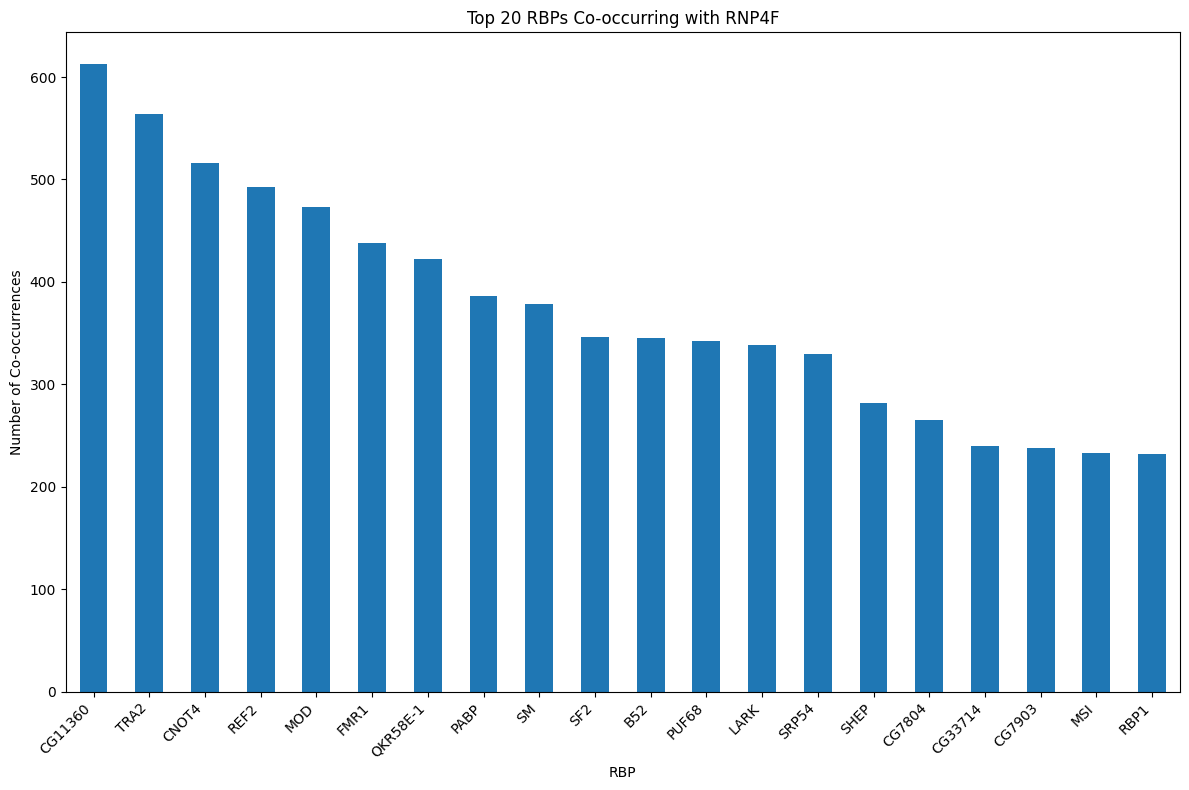

In [49]:
import matplotlib.pyplot as plt

# Count co-occurrences for each RBP with RNP4F
cooccurrence_counts = cooccurrence_df[
    (cooccurrence_df['base_seq_ID'].isin(rnp4f_base_seqs)) & 
    (cooccurrence_df['motif_ALT_ID'] != 'RNP4F')
]['motif_ALT_ID'].value_counts()

print(f"Top 10 RBPs co-occurring with RNP4F:")
print(cooccurrence_counts.head(10))

# Create bar plot
plt.figure(figsize=(12, 8))
cooccurrence_counts.head(20).plot(kind='bar')
plt.title('Top 20 RBPs Co-occurring with RNP4F')
plt.xlabel('RBP')
plt.ylabel('Number of Co-occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [50]:
# Count total instances for each RBP (not just co-occurring with RNP4F)
total_rbp_counts = cooccurrence_df.groupby('motif_ALT_ID').count()['base_seq_ID']

print("Total instances for each RBP:")
print(total_rbp_counts.head(10))

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'total_instances': total_rbp_counts,
    'cooccurring_with_RNP4F': cooccurrence_counts
}).fillna(0)

print("\nComparison of total vs co-occurring instances:")
print(comparison_df.head(10))


Total instances for each RBP:
motif_ALT_ID
A2BP1         2
ARET        232
B52         588
BRU-3         6
CG11360    1384
CG14718     460
CG17838      33
CG2931      343
CG2950      350
CG33714     611
Name: base_seq_ID, dtype: int64

Comparison of total vs co-occurring instances:
              total_instances  cooccurring_with_RNP4F
motif_ALT_ID                                         
A2BP1                       2                     1.0
ARET                      232                   100.0
B52                       588                   345.0
BRU-3                       6                     1.0
CG11360                  1384                   613.0
CG14718                   460                   224.0
CG17838                    33                    10.0
CG2931                    343                   111.0
CG2950                    350                   131.0
CG33714                   611                   240.0


In [53]:
from scipy.stats import hypergeom
import numpy as np

# Parameters for hypergeometric test
total_sequences = len(set(cooccurrence_df['base_seq_ID']))  # Total number of sequences
rnp4f_sequences = len(rnp4f_base_seqs)  # Number of sequences with RNP4F

# Create results dataframe
hypergeom_results = []

for rbp in cooccurring_rbps:
    if rbp != 'RNP4F':  # Skip RNP4F itself
        # Get counts
        rbp_total = total_rbp_counts[rbp]  # Total sequences with this RBP
        cooccurring = int(comparison_df.loc[rbp, 'cooccurring_with_RNP4F'])  # Overlap with RNP4F
        
        # Hypergeometric test
        # P(X >= cooccurring) where X ~ Hypergeom(total_sequences, rbp_total, rnp4f_sequences)
        p_value = hypergeom.sf(cooccurring - 1, total_sequences, rbp_total, rnp4f_sequences)
        
        hypergeom_results.append({
            'RBP': rbp,
            'RBP_total_sequences': rbp_total,
            'RNP4F_sequences': rnp4f_sequences,
            'cooccurring_sequences': cooccurring,
            'expected_overlap': (rbp_total * rnp4f_sequences) / total_sequences,
            'fold_enrichment': cooccurring / ((rbp_total * rnp4f_sequences) / total_sequences),
            'p_value': p_value
        })

hypergeom_df = pd.DataFrame(hypergeom_results).sort_values('p_value')

# Apply Bonferroni correction
hypergeom_df['p_value_bonferroni'] = hypergeom_df['p_value'] * len(hypergeom_df)
hypergeom_df['significant_bonferroni'] = hypergeom_df['p_value_bonferroni'] < 0.05
hypergeom_df = hypergeom_df.reset_index(drop=True)

print("Hypergeometric analysis results (top 20 most significant):")
print(hypergeom_df.head(20))

print(f"\nNumber of RBPs with significant enrichment (Bonferroni corrected p < 0.05): {hypergeom_df['significant_bonferroni'].sum()}")

Hypergeometric analysis results (top 20 most significant):
        RBP  RBP_total_sequences  RNP4F_sequences  cooccurring_sequences  \
0      REF2                  901             1023                    493   
1      TRA2                 1126             1023                    564   
2       B52                  588             1023                    345   
3   CG11360                 1384             1023                    613   
4       SF2                  622             1023                    346   
5       MOD                 1023             1023                    473   
6     SRP54                  686             1023                    330   
7      PABP                  850             1023                    386   
8     CNOT4                 1263             1023                    516   
9     PUF68                  742             1023                    342   
10     FMR1                 1085             1023                    438   
11  CG14718                  

In [54]:
print(total_sequences)
hypergeom_df

3512


,RBP,RBP_total_sequences,RNP4F_sequences,cooccurring_sequences,expected_overlap,fold_enrichment,p_value,p_value_bonferroni,significant_bonferroni
0,REF2,901,1023,493,262.449601,1.878456,1.106038e-80,4.977170e-79,True
1,TRA2,1126,1023,564,327.989180,1.719569,6.334272e-76,2.850422e-74,True
2,B52,588,1023,345,171.276765,2.014284,2.196461e-61,9.884076e-60,True
3,CG11360,1384,1023,613,403.141230,1.520559,1.237022e-56,5.566601e-55,True
4,SF2,622,1023,346,181.180524,1.909698,1.955107e-53,8.797983e-52,True
5,MOD,1023,1023,473,297.986617,1.587320,1.239726e-44,5.578768e-43,True
6,SRP54,686,1023,330,199.822893,1.651462,3.171093e-32,1.426992e-30,True
7,PABP,850,1023,386,247.593964,1.559004,1.065448e-31,4.794517e-30,True
8,CNOT4,1263,1023,516,367.895501,1.402572,6.346045e-30,2.855720e-28,True
9,PUF68,742,1023,342,216.134966,1.582345,7.828150e-29,3.522667e-27,True


In [55]:
AME= pd.read_csv('output/motifs/positive/ame_output/ame.tsv', sep='\t')
hits = AME['motif_alt_ID'][AME['E-value'] < 10].unique()
print(hits)
print(len(hits))
print(hypergeom_df['significant_bonferroni'].sum())

print('hits only', set(hits) - set(hypergeom_df[hypergeom_df['significant_bonferroni']]['RBP'].unique()))
print('hypergeom only', set(hypergeom_df[hypergeom_df['significant_bonferroni']]['RBP'].unique()) - set(hits))
print('both', set(hits) & set(hypergeom_df[hypergeom_df['significant_bonferroni']]['RBP'].unique()))


['RNP4F' 'MOD' 'SF2' 'B52' 'SHEP' 'FMR1' 'CNOT4' 'TRA2' 'QKR58E-1' 'REF2'
 'CG11360' 'LARK' 'SRP54' 'RSF1' 'RBP1' 'CG33714' 'PABP' 'ARET' 'PAPI'
 'SM' 'CG2950' 'MSI' 'CG7804' 'FNE' 'SF1' 'CG2931']
26
28
hits only {'SHEP', 'SF1', 'RNP4F', 'CG2931', 'FNE'}
hypergeom only {'CPO', 'RBP1-LIKE', 'CG14718', 'HRB98DE', 'CG7903', 'HRB87F', 'PUF68'}
both {'RSF1', 'CG11360', 'PABP', 'B52', 'REF2', 'RBP1', 'ARET', 'CNOT4', 'SRP54', 'LARK', 'SF2', 'CG7804', 'QKR58E-1', 'MSI', 'SM', 'TRA2', 'MOD', 'CG2950', 'PAPI', 'CG33714', 'FMR1'}


In [85]:
tomtom = pd.read_csv('output/tomtom_out/tomtom.tsv', sep='\t').dropna()
tomtom['Alt_ID'] = [sequencesMap.loc[i].values[0] for i in tomtom['Target_ID']]
tomtom['hyperRank'] = [hypergeom_df[hypergeom_df['RBP'] == i].index.values+1 for i in tomtom['Alt_ID']]

pd.set_option('display.max_rows', None)
tomtom

,Query_ID,Target_ID,Optimal_offset,p-value,E-value,q-value,Overlap,Query_consensus,Target_consensus,Orientation,Alt_ID,hyperRank
0,RNCMPT00060,RNCMPT00060,0.0,1.262810e-17,8.460810e-16,8.460810e-16,7.0,AGAGAAG,AGAGAAG,+,RNP4F,[]
1,RNCMPT00060,RNCMPT00129,0.0,2.325260e-02,1.557920e+00,7.789610e-01,7.0,AGAGAAG,AGAGUAUA,+,CG11360,[4]
2,RNCMPT00060,RNCMPT00006,2.0,4.492430e-02,3.009930e+00,8.326320e-01,6.0,AGAGAAG,CCAGAUGC,+,CG14718,[12]
3,RNCMPT00060,RNCMPT00078,0.0,6.279700e-02,4.207400e+00,8.326320e-01,7.0,AGAGAAG,GAAGAAG,+,TRA2,[2]
4,RNCMPT00060,RNCMPT00139,-1.0,6.279700e-02,4.207400e+00,8.326320e-01,6.0,AGAGAAG,GAAAAUC,+,PABP,[8]
5,RNCMPT00060,RNCMPT00134,0.0,8.552350e-02,5.730080e+00,8.326320e-01,7.0,AGAGAAG,GGAGGGG,+,B52,[3]
6,RNCMPT00060,RNCMPT00008,0.0,9.941880e-02,6.661060e+00,8.326320e-01,7.0,AGAGAAG,ACACAUA,+,CNOT4,[9]
7,RNCMPT00060,RNCMPT00069,0.0,9.941880e-02,6.661060e+00,8.326320e-01,7.0,AGAGAAG,ACACACA,+,SM,[13]
8,RNCMPT00060,RNCMPT00059,-2.0,1.403250e-01,9.401750e+00,1.000000e+00,5.0,AGAGAAG,AGAAGGC,+,REF2,[1]
9,RNCMPT00060,RNCMPT00015,2.0,1.677990e-01,1.124250e+01,1.000000e+00,5.0,AGAGAAG,ACGGACA,+,FMR1,[11]


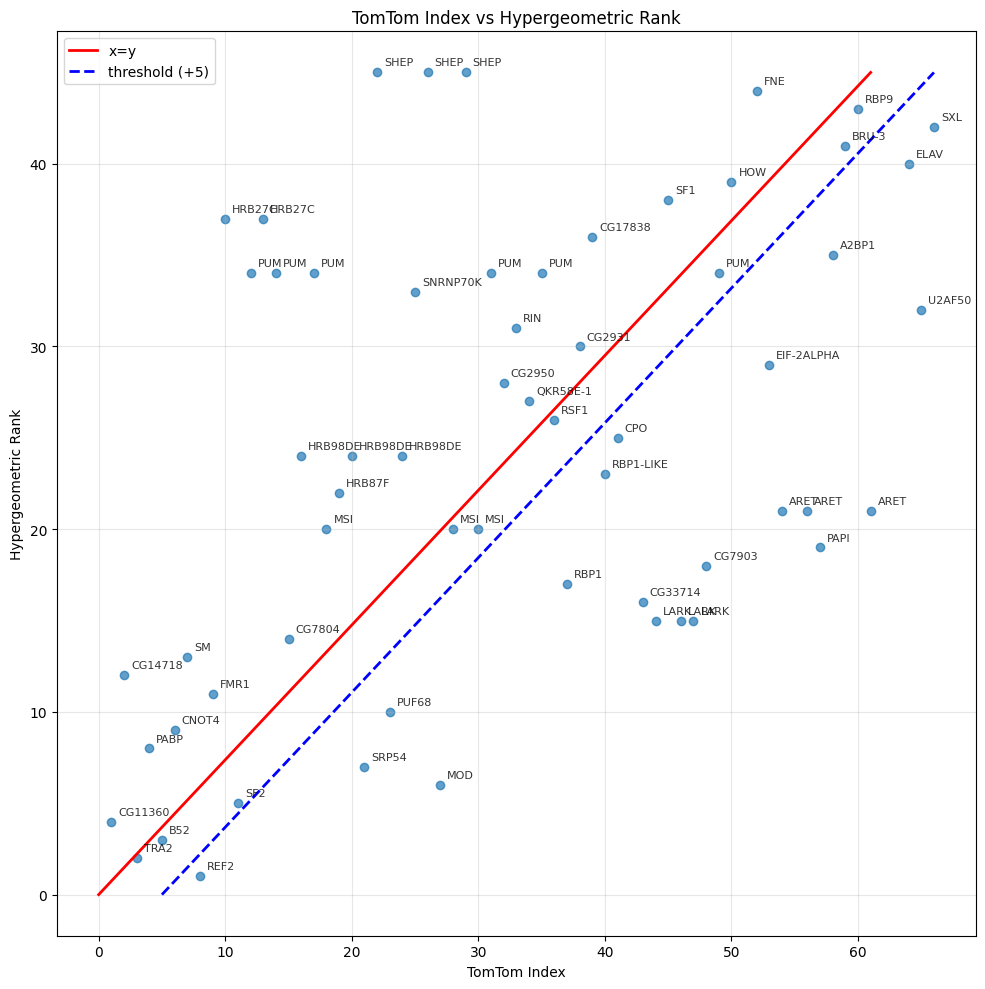

In [90]:
# Filter out rows where hyperRank is empty
filtered_tomtom = tomtom[tomtom['hyperRank'].astype(str) != '[]'].copy()

# Extract the hyperRank values (they are stored as lists, so we need the first element)
hyperrank_values = [rank[0] if len(rank) > 0 else None for rank in filtered_tomtom['hyperRank']]

# Create scatter plot with equal axis lengths
plt.figure(figsize=(10, 10))
plt.scatter(filtered_tomtom.index, hyperrank_values, alpha=0.7)

# Set equal limits for both axes
y_max = max(hyperrank_values)
x_max = len(filtered_tomtom.index)
#plt.xlim(0, max_val)
#plt.ylim(0, max_val)

# Add x=y line in red
plt.plot([0, x_max], [0, y_max], 'r-', linewidth=2, label='x=y')
plt.plot([5, x_max+5], [0, y_max], 'b--', linewidth=2, label='threshold (+5)')

plt.xlabel('TomTom Index')
plt.ylabel('Hypergeometric Rank')
plt.title('TomTom Index vs Hypergeometric Rank')
plt.grid(True, alpha=0.3)
plt.legend()

# Add labels for each point with the RBP name
for i, (idx, rank, rbp) in enumerate(zip(filtered_tomtom.index, hyperrank_values, filtered_tomtom['Alt_ID'])):
    plt.annotate(rbp, (idx, rank), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
hypergeom_df['tomtom_rank'] = [min(tomtom[tomtom['Alt_ID'] == i].index.values) for i in hypergeom_df['RBP']]
# now reverse the ranks
hypergeom_df['tomtom_rank'] = hypergeom_df['tomtom_rank'].max() - hypergeom_df['tomtom_rank'] + 1
hypergeom_df['tomtom_norm_pvalue'] = hypergeom_df['p_value_bonferroni'] * hypergeom_df['tomtom_rank']
hypergeom_df

,RBP,RBP_total_sequences,RNP4F_sequences,cooccurring_sequences,expected_overlap,fold_enrichment,p_value,p_value_bonferroni,significant_bonferroni,tomtom_rank,tomtom_norm_pvalue
0,REF2,901,1023,493,262.449601,1.878456,1.106038e-80,4.977170e-79,True,59,2.936530e-77
1,TRA2,1126,1023,564,327.989180,1.719569,6.334272e-76,2.850422e-74,True,64,1.824270e-72
2,B52,588,1023,345,171.276765,2.014284,2.196461e-61,9.884076e-60,True,62,6.128127e-58
3,CG11360,1384,1023,613,403.141230,1.520559,1.237022e-56,5.566601e-55,True,66,3.673957e-53
4,SF2,622,1023,346,181.180524,1.909698,1.955107e-53,8.797983e-52,True,56,4.926870e-50
5,MOD,1023,1023,473,297.986617,1.587320,1.239726e-44,5.578768e-43,True,40,2.231507e-41
6,SRP54,686,1023,330,199.822893,1.651462,3.171093e-32,1.426992e-30,True,46,6.564162e-29
7,PABP,850,1023,386,247.593964,1.559004,1.065448e-31,4.794517e-30,True,63,3.020545e-28
8,CNOT4,1263,1023,516,367.895501,1.402572,6.346045e-30,2.855720e-28,True,61,1.741989e-26
9,PUF68,742,1023,342,216.134966,1.582345,7.828150e-29,3.522667e-27,True,44,1.549974e-25


In [87]:
hypergeom_df['tomtom_score'] = [min(tomtom[tomtom['Alt_ID'] == i]['p-value']) for i in hypergeom_df['RBP']]
# now reverse the ranks
hypergeom_df['tomtom_score'] = (1 - hypergeom_df['tomtom_score'])/hypergeom_df.shape[0]
hypergeom_df['tomtom_norm_pvalue2'] = hypergeom_df['p_value_bonferroni'] / hypergeom_df['tomtom_score']
hypergeom_df

,RBP,RBP_total_sequences,RNP4F_sequences,cooccurring_sequences,expected_overlap,fold_enrichment,p_value,p_value_bonferroni,significant_bonferroni,tomtom_rank,tomtom_norm_pvalue,tomtom_score,tomtom_norm_pvalue2
0,REF2,901,1023,493,262.449601,1.878456,1.106038e-80,4.977170e-79,True,59,2.936530e-77,1.910389e-02,2.605318e-77
1,TRA2,1126,1023,564,327.989180,1.719569,6.334272e-76,2.850422e-74,True,64,1.824270e-72,2.082673e-02,1.368636e-72
2,B52,588,1023,345,171.276765,2.014284,2.196461e-61,9.884076e-60,True,62,6.128127e-58,2.032170e-02,4.863804e-58
3,CG11360,1384,1023,613,403.141230,1.520559,1.237022e-56,5.566601e-55,True,66,3.673957e-53,2.170550e-02,2.564604e-53
4,SF2,622,1023,346,181.180524,1.909698,1.955107e-53,8.797983e-52,True,56,4.926870e-50,1.659393e-02,5.301927e-50
5,MOD,1023,1023,473,297.986617,1.587320,1.239726e-44,5.578768e-43,True,40,2.231507e-41,1.220211e-02,4.571970e-41
6,SRP54,686,1023,330,199.822893,1.651462,3.171093e-32,1.426992e-30,True,46,6.564162e-29,1.443431e-02,9.886109e-29
7,PABP,850,1023,386,247.593964,1.559004,1.065448e-31,4.794517e-30,True,63,3.020545e-28,2.082673e-02,2.302097e-28
8,CNOT4,1263,1023,516,367.895501,1.402572,6.346045e-30,2.855720e-28,True,61,1.741989e-26,2.001292e-02,1.426939e-26
9,PUF68,742,1023,342,216.134966,1.582345,7.828150e-29,3.522667e-27,True,44,1.549974e-25,1.389836e-02,2.534593e-25


In [10]:
RNP4F_REF2 = set(cooccurrence_df[cooccurrence_df['motif_ALT_ID'] == 'RNP4F']['base_seq_ID']).intersection(set(cooccurrence_df[cooccurrence_df['motif_ALT_ID'] == 'REF2']['base_seq_ID']))
print(len(RNP4F_REF2))
RNP4F_REF2

493


{'motif_seq_0',
 'motif_seq_1000',
 'motif_seq_1002',
 'motif_seq_1005',
 'motif_seq_1006',
 'motif_seq_1014',
 'motif_seq_1023',
 'motif_seq_1053',
 'motif_seq_1074',
 'motif_seq_1078',
 'motif_seq_1093',
 'motif_seq_1111',
 'motif_seq_1127',
 'motif_seq_1142',
 'motif_seq_116',
 'motif_seq_1162',
 'motif_seq_1168',
 'motif_seq_1178',
 'motif_seq_1182',
 'motif_seq_1184',
 'motif_seq_1193',
 'motif_seq_1203',
 'motif_seq_1207',
 'motif_seq_1237',
 'motif_seq_1239',
 'motif_seq_1250',
 'motif_seq_1269',
 'motif_seq_1286',
 'motif_seq_1300',
 'motif_seq_1301',
 'motif_seq_1311',
 'motif_seq_1323',
 'motif_seq_1326',
 'motif_seq_133',
 'motif_seq_1333',
 'motif_seq_1340',
 'motif_seq_1343',
 'motif_seq_1345',
 'motif_seq_1348',
 'motif_seq_1353',
 'motif_seq_1355',
 'motif_seq_1357',
 'motif_seq_1364',
 'motif_seq_1367',
 'motif_seq_1370',
 'motif_seq_1376',
 'motif_seq_1383',
 'motif_seq_1403',
 'motif_seq_1416',
 'motif_seq_1427',
 'motif_seq_1428',
 'motif_seq_1431',
 'motif_seq_1439'

In [17]:
fullDF[(fullDF['base_seq_ID'] == 'motif_seq_0') & (fullDF['motif_ALT_ID'].isin(['RNP4F','REF2']))]

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID
27994,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00059,REF2,motif_seq_0_2,3.0,3.84236,tp,motif_seq_0
28291,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00059,REF2,motif_seq_0_1,2.0,2.30345,tp,motif_seq_0
28904,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motif_seq_0_1,2.0,16.65580,tp,motif_seq_0


In [4]:
len(fullDF['motif_ALT_ID'].unique())

51

In [6]:
a = pd.read_csv('output/motifs/positive/ame_output/ame.tsv', sep='\t')
print(len(a[a['E-value'] < 10]['motif_alt_ID'].unique()))
print(len(a[a['E-value'] < 10]['motif_alt_ID']))

26
34










# on same transcript, but not same location

In [ ]:
import pandas as pd

# Read the TSV file to find RBPs that co-occur with RNP4F
sequences = pd.read_csv('output/motifs/positive/ame_output/sequences.tsv', sep='\t')
sequences = sequences[
    sequences['seq_ID'].notna() & 
    ~sequences['seq_ID'].str.contains('control', na=False)
]
print(sequences.shape)
locations = pd.read_csv('output/fimo_out/fimo.tsv', sep='\t')
locations = locations[locations['motif_alt_id'].notna()]
print(locations.shape)
sequences = sequences[sequences['motif_ALT_ID'].isin(locations['motif_alt_id'].unique())]
print(sequences.shape)
sequences['base_seq_ID'] = sequences['seq_ID'].str.rsplit('.', n=1).str[0]
#locations['loc'] = [f"{locations['sequence_name'].iloc[i]}_{int(locations['start'].iloc[i])}_{int(locations['stop'].iloc[i])}" for i in range(locations.shape[0])]


(29872, 7)
(630476, 10)
1         A2BP1
2         A2BP1
1438      BRU-3
1439      BRU-3
1440      BRU-3
          ...  
40576    U2AF50
40577    U2AF50
40578    U2AF50
40579    U2AF50
40580    U2AF50
Name: motif_ALT_ID, Length: 6155, dtype: object
(23717, 7)


In [22]:
locations = locations[~locations[['motif_alt_id', 'sequence_name']].duplicated()]
print(locations.shape)

(139598, 10)


In [23]:

# Create a merged dataframe to avoid repeated lookups
merged = sequences.merge(
    locations, 
    left_on=['motif_ALT_ID', 'seq_ID'], 
    right_on=['motif_alt_id', 'sequence_name'],
    how='left'
)



In [24]:
merged

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_2734.3,6129.0,2776.60000,tp,motifSeq_2734,RNCMPT00114,ARET,motifSeq_2734.3,5.0,12.0,+,11.96800,0.00003,0.0174,UGUGUGUG
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_905.0,1946.0,1926.36000,tp,motifSeq_905,RNCMPT00114,ARET,motifSeq_905.0,1.0,8.0,+,11.96800,0.00003,0.0174,UGUGUGUG
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_2511.1,5551.0,1750.98000,tp,motifSeq_2511,RNCMPT00114,ARET,motifSeq_2511.1,3.0,10.0,+,11.96800,0.00003,0.0174,UGUGUGUG
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_1659.3,3718.0,1579.20000,tp,motifSeq_1659,RNCMPT00114,ARET,motifSeq_1659.3,5.0,12.0,+,11.96800,0.00003,0.0174,UGUGUGUG
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_2940.1,6650.0,1484.70000,tp,motifSeq_2940,RNCMPT00114,ARET,motifSeq_2940.1,8.0,15.0,+,11.96800,0.00003,0.0174,UGUGUGUG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23712,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_3116.0,7055.0,1.21010,tp,motifSeq_3116,RNCMPT00078,TRA2,motifSeq_3116.0,10.0,16.0,+,4.83333,0.00464,0.2240,GCAGAAA
23713,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_3606.0,8141.0,1.20883,tp,motifSeq_3606,RNCMPT00078,TRA2,motifSeq_3606.0,16.0,22.0,+,5.66667,0.00269,0.1750,CAGGAAU
23714,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_3054.0,6935.0,1.20883,tp,motifSeq_3054,RNCMPT00078,TRA2,motifSeq_3054.0,4.0,10.0,+,4.70139,0.00525,0.2360,UAGGAAU
23715,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_4083.2,9215.0,1.20873,tp,motifSeq_4083,RNCMPT00078,TRA2,motifSeq_4083.2,16.0,22.0,+,5.25694,0.00372,0.1990,GAAGAUG


In [25]:
rbpOfInterest = 'RNP4F'
rbpOfInt = merged[merged['motif_ALT_ID'] == rbpOfInterest]
rbpOfInt

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
15267,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_3344.1,7551.0,150.20200,tp,motifSeq_3344,RNCMPT00060,RNP4F,motifSeq_3344.1,5.0,11.0,+,11.00000,0.000061,0.168,AGAGAAG
15268,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_1837.0,4110.0,138.83300,tp,motifSeq_1837,RNCMPT00060,RNP4F,motifSeq_1837.0,4.0,10.0,+,9.78698,0.000183,0.168,AGAGAGG
15269,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_2620.0,5828.0,113.49400,tp,motifSeq_2620,RNCMPT00060,RNP4F,motifSeq_2620.0,1.0,7.0,+,11.00000,0.000061,0.168,AGAGAAG
15270,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_351.1,722.0,92.42510,tp,motifSeq_351,RNCMPT00060,RNP4F,motifSeq_351.1,2.0,8.0,+,9.78698,0.000183,0.168,AGAGAGG
15271,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_1590.3,3541.0,85.85110,tp,motifSeq_1590,RNCMPT00060,RNP4F,motifSeq_1590.3,1.0,7.0,+,9.21302,0.000305,0.168,AGAGAGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16466,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_1416.1,3116.0,1.26773,tp,motifSeq_1416,RNCMPT00060,RNP4F,motifSeq_1416.1,4.0,10.0,+,6.04734,0.002440,0.258,ACAGAAA
16467,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_37.1,56.0,1.26763,tp,motifSeq_37,RNCMPT00060,RNP4F,motifSeq_37.1,10.0,16.0,+,2.65680,0.014300,0.330,GGAGGGA
16468,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_2469.0,5458.0,1.26700,tp,motifSeq_2469,RNCMPT00060,RNP4F,motifSeq_2469.0,65.0,71.0,+,6.62130,0.001710,0.258,AAAGAAG
16469,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00060,RNP4F,motifSeq_2649.0,5901.0,1.26582,tp,motifSeq_2649,RNCMPT00060,RNP4F,motifSeq_2649.0,71.0,77.0,+,6.21893,0.001950,0.258,AGAGAGC


In [28]:
filtDF = pd.DataFrame(columns=merged.columns)
for i in range(rbpOfInt.shape[0]):
    tmpDF = merged[merged['base_seq_ID'] == rbpOfInt.iloc[i]['base_seq_ID']]
    # check if the start and stop positions in the tmpDF overlap with the RBP of interest start and stop positions, if they do, remove that row from the tmpDF
    tmpDF = tmpDF[~((tmpDF['seq_ID'] == rbpOfInt.iloc[i]['seq_ID']) & (tmpDF['start'] >= rbpOfInt.iloc[i]['start']) & (tmpDF['start'] < rbpOfInt.iloc[i]['stop'])) & ~((tmpDF['seq_ID'] == rbpOfInt.iloc[i]['seq_ID']) &(tmpDF['stop'] > rbpOfInt.iloc[i]['start']) & (tmpDF['stop'] <= rbpOfInt.iloc[i]['stop'])) & ~((tmpDF['seq_ID'] == rbpOfInt.iloc[i]['seq_ID']) &(tmpDF['start'] <= rbpOfInt.iloc[i]['start']) & (tmpDF['stop'] >= rbpOfInt.iloc[i]['stop']))]
    filtDF = pd.concat([filtDF, tmpDF], ignore_index=True)

In [29]:
filtDF

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00008,CNOT4,motifSeq_3344.0,7550.0,1.57368,tp,motifSeq_3344,RNCMPT00008,CNOT4,motifSeq_3344.0,4.0,10.0,+,4.95105,0.003360,0.122,AAACAAC
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,motifSeq_3344.0,7550.0,10.44730,tp,motifSeq_3344,RNCMPT00058,RBP1,motifSeq_3344.0,6.0,12.0,+,7.39161,0.000977,0.244,ACAACUA
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_3344.0,7550.0,2.35383,tp,motifSeq_3344,RNCMPT00078,TRA2,motifSeq_3344.0,4.0,10.0,+,5.73611,0.002200,0.175,AAACAAC
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_2620.0,5828.0,31.17500,tp,motifSeq_2620,RNCMPT00134,B52,motifSeq_2620.0,7.0,13.0,+,7.79861,0.000977,0.618,GGAGGAU
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00129,CG11360,motifSeq_2620.0,5828.0,1.21897,tp,motifSeq_2620,RNCMPT00129,CG11360,motifSeq_2620.0,7.0,14.0,+,5.40000,0.003860,0.311,GGAGGAUG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10467,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00065,SF1,motifSeq_2841.0,6394.0,1.51279,tp,motifSeq_2841,RNCMPT00065,SF1,motifSeq_2841.0,28.0,34.0,+,7.72028,0.000610,0.328,ACUAAAA
10468,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00066,SF2,motifSeq_2841.4,6398.0,13.74990,tp,motifSeq_2841,RNCMPT00066,SF2,motifSeq_2841.4,4.0,10.0,+,4.99301,0.002690,0.740,CGGAGGC
10469,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00069,SM,motifSeq_2841.3,6397.0,558.76200,tp,motifSeq_2841,RNCMPT00069,SM,motifSeq_2841.3,1.0,7.0,+,11.70630,0.000061,0.031,ACACACA
10470,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00272,SRP54,motifSeq_2841.4,6398.0,22.90900,tp,motifSeq_2841,RNCMPT00272,SRP54,motifSeq_2841.4,5.0,11.0,+,5.87413,0.004330,1.000,GGAGGCG


In [55]:
filtDF = filtDF[~filtDF[['motif_ALT_ID', 'base_seq_ID']].duplicated()]
filtDF

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00008,CNOT4,motifSeq_3344.0,7550.0,1.57368,tp,motifSeq_3344,RNCMPT00008,CNOT4,motifSeq_3344.0,4.0,10.0,+,4.95105,0.003360,0.122,AAACAAC
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,motifSeq_3344.0,7550.0,10.44730,tp,motifSeq_3344,RNCMPT00058,RBP1,motifSeq_3344.0,6.0,12.0,+,7.39161,0.000977,0.244,ACAACUA
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00078,TRA2,motifSeq_3344.0,7550.0,2.35383,tp,motifSeq_3344,RNCMPT00078,TRA2,motifSeq_3344.0,4.0,10.0,+,5.73611,0.002200,0.175,AAACAAC
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_2620.0,5828.0,31.17500,tp,motifSeq_2620,RNCMPT00134,B52,motifSeq_2620.0,7.0,13.0,+,7.79861,0.000977,0.618,GGAGGAU
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00129,CG11360,motifSeq_2620.0,5828.0,1.21897,tp,motifSeq_2620,RNCMPT00129,CG11360,motifSeq_2620.0,7.0,14.0,+,5.40000,0.003860,0.311,GGAGGAUG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10447,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00140,MOD,motifSeq_2649.0,5901.0,7.07103,tp,motifSeq_2649,RNCMPT00140,MOD,motifSeq_2649.0,15.0,21.0,+,8.69231,0.000427,0.324,CGUGGAA
10448,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,motifSeq_2649.0,5901.0,19.72620,tp,motifSeq_2649,RNCMPT00058,RBP1,motifSeq_2649.0,58.0,64.0,+,10.81820,0.000122,0.092,ACAACGG
10449,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00061,RSF1,motifSeq_2649.0,5901.0,1.38130,tp,motifSeq_2649,RNCMPT00061,RSF1,motifSeq_2649.0,61.0,67.0,+,5.86014,0.001890,0.765,ACGGCGA
10450,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00069,SM,motifSeq_2649.0,5901.0,3.00608,tp,motifSeq_2649,RNCMPT00069,SM,motifSeq_2649.0,42.0,48.0,+,8.02797,0.000793,0.179,AUACACG


In [56]:
# Find all RBPs that co-occur with RNP4F (same base_seq_ID)
cooccurring_rbps = filtDF['motif_ALT_ID'].unique()

print(f"RBPs that co-occur with RNP4F: {len(cooccurring_rbps)}")
print(cooccurring_rbps)

RBPs that co-occur with RNP4F: 25
['CNOT4' 'RBP1' 'TRA2' 'B52' 'CG11360' 'SRP54' 'PABP' 'CG7804' 'FMR1'
 'REF2' 'SF2' 'SHEP' 'CG33714' 'LARK' 'MSI' 'RNP4F' 'SM' 'MOD' 'RSF1'
 'CG2931' 'CG2950' 'SF1' 'ARET' 'PAPI' 'FNE']


In [ ]:
# Count co-occurrences for each RBP with RNP4F
cooccurrence_counts = filtDF['motif_ALT_ID'].value_counts()
cooccurrence_counts

motif_ALT_ID
CG11360    447
CNOT4      443
TRA2       423
FMR1       383
MOD        382
LARK       326
PABP       322
SM         308
REF2       299
SF2        266
SRP54      265
SHEP       251
B52        250
CG7804     240
CG33714    233
RBP1       225
MSI        205
SF1        174
RNP4F      165
RSF1       155
CG2931     106
CG2950     106
ARET        99
PAPI        93
FNE          4
Name: count, dtype: int64

In [58]:
allNoOverlap = pd.concat([merged[~merged['base_seq_ID'].isin(rbpOfInt['base_seq_ID'].unique())], filtDF], ignore_index=True)
allNoOverlap

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_905.0,1946.0,1926.36000,tp,motifSeq_905,RNCMPT00114,ARET,motifSeq_905.0,1.0,8.0,+,11.96800,0.000030,0.0174,UGUGUGUG
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3015.0,6837.0,1394.62000,tp,motifSeq_3015,RNCMPT00114,ARET,motifSeq_3015.0,2.0,9.0,+,12.37600,0.000015,0.0174,UGUGUGUU
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3733.2,8433.0,1382.59000,tp,motifSeq_3733,RNCMPT00114,ARET,motifSeq_3733.2,12.0,19.0,+,12.37600,0.000015,0.0174,UGUGUGUU
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3649.2,8249.0,1190.50000,tp,motifSeq_3649,RNCMPT00114,ARET,motifSeq_3649.2,5.0,12.0,+,12.37600,0.000015,0.0174,UGUGUGUU
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_1868.4,4182.0,1074.40000,tp,motifSeq_1868,RNCMPT00114,ARET,motifSeq_1868.4,20.0,27.0,+,11.96800,0.000030,0.0174,UGUGUGUG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18916,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00140,MOD,motifSeq_2649.0,5901.0,7.07103,tp,motifSeq_2649,RNCMPT00140,MOD,motifSeq_2649.0,15.0,21.0,+,8.69231,0.000427,0.3240,CGUGGAA
18917,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,motifSeq_2649.0,5901.0,19.72620,tp,motifSeq_2649,RNCMPT00058,RBP1,motifSeq_2649.0,58.0,64.0,+,10.81820,0.000122,0.0920,ACAACGG
18918,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00061,RSF1,motifSeq_2649.0,5901.0,1.38130,tp,motifSeq_2649,RNCMPT00061,RSF1,motifSeq_2649.0,61.0,67.0,+,5.86014,0.001890,0.7650,ACGGCGA
18919,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00069,SM,motifSeq_2649.0,5901.0,3.00608,tp,motifSeq_2649,RNCMPT00069,SM,motifSeq_2649.0,42.0,48.0,+,8.02797,0.000793,0.1790,AUACACG


In [59]:
allNoOverlap = allNoOverlap[~allNoOverlap[['motif_ALT_ID', 'base_seq_ID']].duplicated()]
allNoOverlap

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_905.0,1946.0,1926.36000,tp,motifSeq_905,RNCMPT00114,ARET,motifSeq_905.0,1.0,8.0,+,11.96800,0.000030,0.0174,UGUGUGUG
1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3015.0,6837.0,1394.62000,tp,motifSeq_3015,RNCMPT00114,ARET,motifSeq_3015.0,2.0,9.0,+,12.37600,0.000015,0.0174,UGUGUGUU
2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3733.2,8433.0,1382.59000,tp,motifSeq_3733,RNCMPT00114,ARET,motifSeq_3733.2,12.0,19.0,+,12.37600,0.000015,0.0174,UGUGUGUU
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_3649.2,8249.0,1190.50000,tp,motifSeq_3649,RNCMPT00114,ARET,motifSeq_3649.2,5.0,12.0,+,12.37600,0.000015,0.0174,UGUGUGUU
4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00270,ARET,motifSeq_1868.4,4182.0,1074.40000,tp,motifSeq_1868,RNCMPT00114,ARET,motifSeq_1868.4,20.0,27.0,+,11.96800,0.000030,0.0174,UGUGUGUG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18916,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00140,MOD,motifSeq_2649.0,5901.0,7.07103,tp,motifSeq_2649,RNCMPT00140,MOD,motifSeq_2649.0,15.0,21.0,+,8.69231,0.000427,0.3240,CGUGGAA
18917,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00058,RBP1,motifSeq_2649.0,5901.0,19.72620,tp,motifSeq_2649,RNCMPT00058,RBP1,motifSeq_2649.0,58.0,64.0,+,10.81820,0.000122,0.0920,ACAACGG
18918,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00061,RSF1,motifSeq_2649.0,5901.0,1.38130,tp,motifSeq_2649,RNCMPT00061,RSF1,motifSeq_2649.0,61.0,67.0,+,5.86014,0.001890,0.7650,ACGGCGA
18919,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00069,SM,motifSeq_2649.0,5901.0,3.00608,tp,motifSeq_2649,RNCMPT00069,SM,motifSeq_2649.0,42.0,48.0,+,8.02797,0.000793,0.1790,AUACACG


In [60]:
# Count total instances for each RBP (not just co-occurring with RNP4F)
total_rbp_counts = allNoOverlap.groupby('motif_ALT_ID').count()['seq_ID']

print("Total instances for each RBP:")
print(total_rbp_counts.head(10))

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'total_instances': total_rbp_counts,
    'cooccurring_with_RNP4F': cooccurrence_counts
}).fillna(0)

print("\nComparison of total vs co-occurring instances:")
comparison_df

Total instances for each RBP:
motif_ALT_ID
ARET        231
B52         493
CG11360    1218
CG2931      338
CG2950      325
CG33714     604
CG5213        2
CG7804      561
CNOT4      1190
FMR1       1030
Name: seq_ID, dtype: int64

Comparison of total vs co-occurring instances:


,total_instances,cooccurring_with_RNP4F
motif_ALT_ID,,
ARET,231,99.0
B52,493,250.0
CG11360,1218,447.0
CG2931,338,106.0
CG2950,325,106.0
CG33714,604,233.0
CG5213,2,0.0
CG7804,561,240.0
CNOT4,1190,443.0


In [61]:
from scipy.stats import hypergeom
import numpy as np

# Parameters for hypergeometric test
total_sequences = len(set(allNoOverlap['base_seq_ID']))  # Total number of sequences
print(f"Total sequences: {total_sequences}")
rnp4f_sequences = len(set(rbpOfInt['base_seq_ID']))  # Number of sequences with RNP4F

# Create results dataframe
hypergeom_results = []

for rbp in cooccurring_rbps:
    if rbp != 'RNP4F':  # Skip RNP4F itself
        # Get counts
        rbp_total = total_rbp_counts[rbp]  # Total sequences with this RBP
        cooccurring = int(comparison_df.loc[rbp, 'cooccurring_with_RNP4F'])  # Overlap with RNP4F
        
        # Hypergeometric test
        # P(X >= cooccurring) where X ~ Hypergeom(total_sequences, rbp_total, rnp4f_sequences)
        p_value = hypergeom.sf(cooccurring - 1, total_sequences, rbp_total, rnp4f_sequences)
        
        hypergeom_results.append({
            'RBP': rbp,
            'RBP_total_sequences': rbp_total,
            'RNP4F_sequences': rnp4f_sequences,
            'cooccurring_sequences': cooccurring,
            'expected_overlap': (rbp_total * rnp4f_sequences) / total_sequences,
            'fold_enrichment': cooccurring / ((rbp_total * rnp4f_sequences) / total_sequences),
            'p_value': p_value
        })

hypergeom_df = pd.DataFrame(hypergeom_results).sort_values('p_value')

# Apply Bonferroni correction
hypergeom_df['p_value_bonferroni'] = hypergeom_df['p_value'] * len(hypergeom_df)
hypergeom_df['significant_bonferroni'] = hypergeom_df['p_value_bonferroni'] < 0.05
hypergeom_df = hypergeom_df.reset_index(drop=True)


print(f"\nNumber of RBPs with significant enrichment (Bonferroni corrected p < 0.05): {hypergeom_df['significant_bonferroni'].sum()}")
print("Hypergeometric analysis results (top 20 most significant):")
hypergeom_df

Total sequences: 3319

Number of RBPs with significant enrichment (Bonferroni corrected p < 0.05): 17
Hypergeometric analysis results (top 20 most significant):


,RBP,RBP_total_sequences,RNP4F_sequences,cooccurring_sequences,expected_overlap,fold_enrichment,p_value,p_value_bonferroni,significant_bonferroni
0,B52,493,1023,250,151.955107,1.645223,9.409495e-24,2.258279e-22,True
1,SF2,538,1023,266,165.825249,1.604098,3.058435e-23,7.340243e-22,True
2,TRA2,985,1023,423,303.601989,1.393272,2.702448e-22,6.485875e-21,True
3,MOD,932,1023,382,287.266044,1.329778,3.827365e-15,9.185676e-14,True
4,REF2,703,1023,299,216.682434,1.379900,7.782189e-14,1.867725e-12,True
5,SRP54,621,1023,265,191.407954,1.384477,2.599388e-12,6.238530e-11,True
6,PABP,786,1023,322,242.265140,1.329122,2.722319e-12,6.533566e-11,True
7,CG7804,561,1023,240,172.914432,1.387970,3.181336e-11,7.635207e-10,True
8,CNOT4,1190,1023,443,366.788189,1.207782,1.853791e-09,4.449098e-08,True
9,CG11360,1218,1023,447,375.418500,1.190671,1.765663e-08,4.237592e-07,True


In [62]:
filtDF[filtDF['motif_ALT_ID'] == 'B52']

,motif_DB,motif_ID,motif_ALT_ID,seq_ID,FASTA_score,PWM_score,class,base_seq_ID,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_2620.0,5828.0,31.17500,tp,motifSeq_2620,RNCMPT00134,B52,motifSeq_2620.0,7.0,13.0,+,7.79861,0.000977,0.618,GGAGGAU
19,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_1431.1,3160.0,41.05150,tp,motifSeq_1431,RNCMPT00134,B52,motifSeq_1431.1,23.0,29.0,+,10.00000,0.000244,0.313,GGAGGAG
66,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_824.0,1789.0,7.48933,tp,motifSeq_824,RNCMPT00134,B52,motifSeq_824.0,1.0,7.0,+,5.56250,0.001590,0.765,GGAGGUG
88,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_415.2,875.0,2.44860,tp,motifSeq_415,RNCMPT00134,B52,motifSeq_415.2,3.0,9.0,+,4.49306,0.004210,0.765,AGAGGGC
100,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_480.0,1026.0,15.77060,tp,motifSeq_480,RNCMPT00134,B52,motifSeq_480.0,28.0,34.0,+,9.54861,0.000305,0.329,GGAGGAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10236,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_2761.0,6200.0,1.38308,tp,motifSeq_2761,RNCMPT00134,B52,motifSeq_2761.0,64.0,70.0,+,5.06944,0.002560,0.765,GGAGCGG
10241,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_3850.4,8698.0,3.57754,tp,motifSeq_3850,RNCMPT00134,B52,motifSeq_3850.4,1.0,7.0,+,3.39583,0.006100,0.765,GGCGGAA
10295,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_1438.2,3183.0,2.63087,tp,motifSeq_1438,RNCMPT00134,B52,motifSeq_1438.2,12.0,18.0,+,3.84722,0.005190,0.765,AGAGGAG
10346,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00134,B52,motifSeq_3632.0,8208.0,1.78777,tp,motifSeq_3632,RNCMPT00134,B52,motifSeq_3632.0,12.0,18.0,+,5.06944,0.002560,0.765,UGAGGGG
